# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and PCA
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
PCA_COMPONENTS = cfg.PCA_COMPONENTS  # 50
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = 40

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 5.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=2000,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (2000, 4)
Energy telemetry shape: (16246, 5)
Baseline feature frame: (16054, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.70s
  CPU usage: 27.1% • IO wait: 0.00%
  Disk Δ: +56.6 MB read, +1.0 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 2000
  Energy records: 16246
  Master records: 16054


### Inspect Data

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    6605
 1.0    6331
 0.0    3118
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    41.142394
 1.0    39.435655
 0.0    19.421951
Name: proportion, dtype: float64


# Plot comprehensive EDA dashboard
visualization.plot_eda_dashboard(
    master_df=master_df,
    news_df=news_df,
)

## 5. Stage 2: News Processing - Topic Classification

In [6]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


Device set to use mps


Processing 2000 texts with batch_size=128
Classification completed: 2000 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot           731
sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage                  249
die Großhandelspreise für Erdgas steigen                                             210
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken      172
der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot          150
geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung           139
der Stromverbrauch in Deutschland steigt                                             115
der Stromverbrauch in Deutschland fällt                                              100
die Stromerzeugung aus Wind und Sonne steigt                                          63
steigende Zinsen oder

## 6. Stage 2B: Sentence Embeddings

In [7]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Using MPS (Apple Silicon) acceleration for embeddings
Using batch_size=128 for embedding computation on device=mps


Batches: 100%|██████████| 16/16 [00:01<00:00,  9.43it/s]


Embeddings computed: shape (2000, 384)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 6.45s
  CPU usage: 39.2% • IO wait: 0.00%
  Disk Δ: +630.6 MB read, +696.3 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


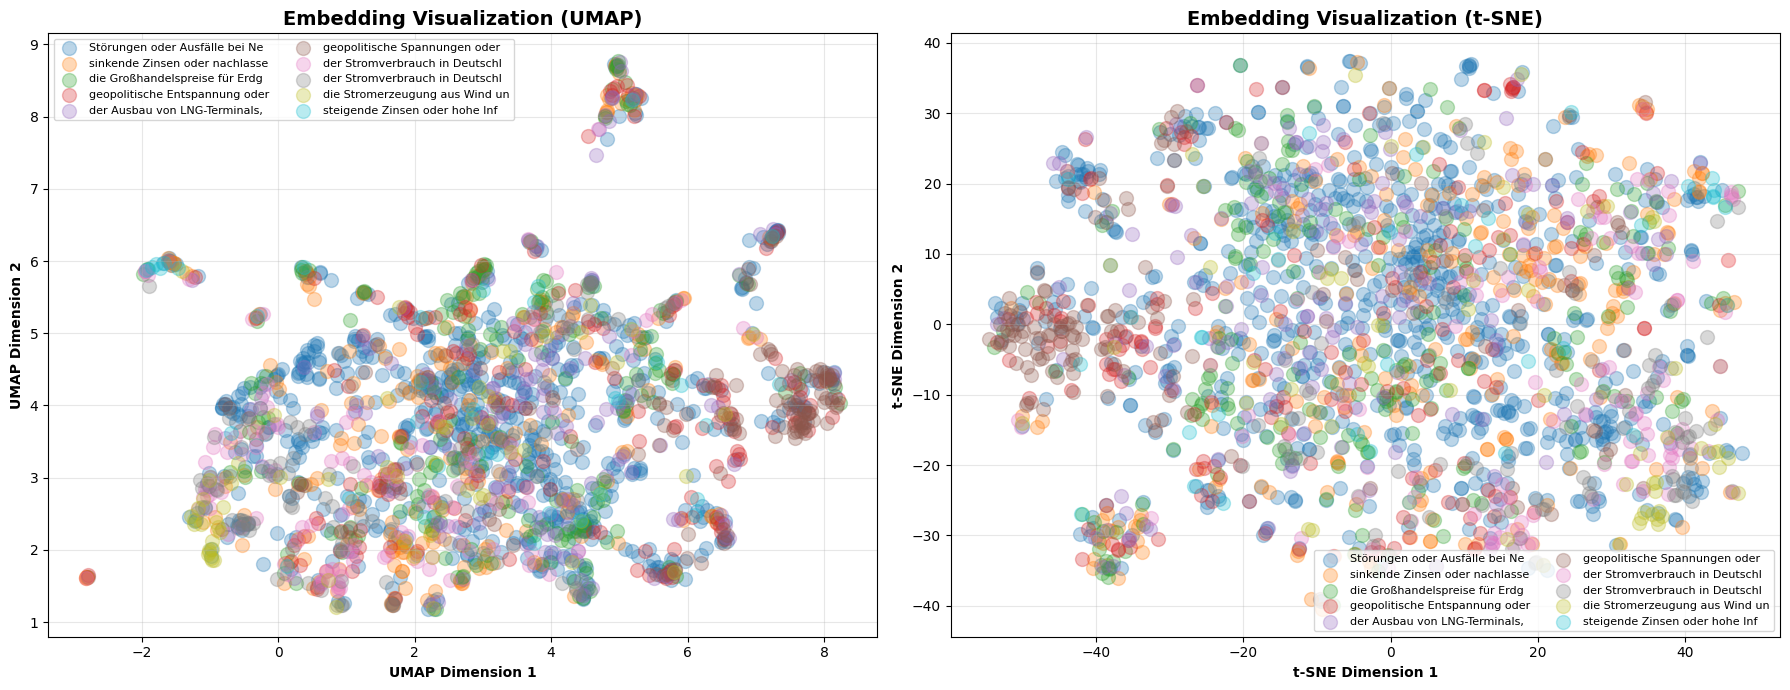

In [8]:
visualization.plot_embedding_quality(news_df=news_df, n_samples=2000, perplexity=30)

## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [9]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        n_components=PCA_COMPONENTS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 9 parameter combinations...
[1/9] lookback=168h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[2/9] lookback=168h, decay_lambda=0.05
Embedding reduction backend: umap-learn
[3/9] lookback=168h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[4/9] lookback=336h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[5/9] lookback=336h, decay_lambda=0.05
Embedding reduction backend: umap-learn
[6/9] lookback=336h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[7/9] lookback=504h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[8/9] lookback=504h, decay_lambda=0.05
Embedding reduction backend: umap-learn
[9/9] lookback=504h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 59.93s
  CPU usage: 50.6% • IO wait: 0.00%
  Disk Δ: +493.0 MB read, +119.7 MB written
  G

In [10]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        dataset_prefix="td_dataset",
    )

sample_params_key = next(iter(preprocessed_datasets))
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Prepared datasets: {len(preprocessed_datasets)}")
print(
    f"  Sample dataset: {sample_dataset['dataset_name']} -> "
    f"train={len(sample_dataset['train_df'])}, "
    f"val={len(sample_dataset['val_df'])}, "
    f"test={len(sample_dataset['test_df'])}"
)


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.06s
  CPU usage: 28.3% • IO wait: 0.00%
  Disk Δ: +0.4 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset assembly complete
  Prepared datasets: 9
  Sample dataset: td_dataset_lw168_dl0.01 -> train=11237, val=3210, test=1607


## 8. Stage 3C: Dataset Scaling & Summary

In [11]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.18s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +1.1 MB read, +0.3 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset scaling complete
  Scaled news features per dataset: 64
  Sample scaled features: ['die Großhandelspreise für Erdgas steigen_scaled', 'der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot_scaled', 'geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung_scaled', 'Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot_scaled', 'sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage_scaled']


## 9. Stage 3D: Feature Selection with RidgeCV

In [12]:
# Baseline (price + temporal) features stay fixed across datasets
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168",
    "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# News feature definitions come from the assembled datasets
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline features: {len(baseline_features)}")
print(f"  Topic features: {len(topic_features)}")
print(f"  Embedding features: {len(embedding_features)}")
print(f"  Total news features: {len(news_features)}")

with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_3_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_3_combinations:
    best_params_key = top_3_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(
        f"\n✓ Top parameter combination: {best_dataset['dataset_name']} "
        f"(lookback={top_3_combinations[0]['lookback_window']}h, "
        f"lambda={top_3_combinations[0]['decay_lambda']})"
    )
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline features: 13
  Topic features: 14
  Embedding features: 50
  Total news features: 64

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 9 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:    9.2s remaining:   32.0s
[Parallel(n_jobs=-1)]: Done   3 out of   9 | elapsed:    9.2s remaining:   18.3s
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:    9.2s remaining:   11.5s
[Parallel(n_jobs=-1)]: Done   5 out of   9 | elapsed:    9.2s remaining:    7.3s
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:    9.2s remaining:    4.6s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:    9.2s remaining:    2.6s


TOP 3 PARAMETER COMBINATIONS:
1. dataset=td_dataset_lw168_dl0.05 | lookback=168h | lambda=0.05 | alpha=1000.0000 | Val Accuracy=0.485 | Val Macro-F1=0.357
2. dataset=td_dataset_lw168_dl0.01 | lookback=168h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.484 | Val Macro-F1=0.360
3. dataset=td_dataset_lw168_dl0.1 | lookback=168h | lambda=0.1 | alpha=1000.0000 | Val Accuracy=0.479 | Val Macro-F1=0.353
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 9.80s
  CPU usage: 75.6% • IO wait: 0.00%
  Disk Δ: +250.6 MB read, +1703.7 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Top parameter combination: td_dataset_lw168_dl0.05 (lookback=168h, lambda=0.05)


[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    9.7s finished


## 10. Stage 3E: Summarise Ridge Results

In [13]:
if top_3_combinations:
    top_3_summary = pd.DataFrame([
        {
            "dataset_name": res["dataset_name"],
            "lookback_window": res["lookback_window"],
            "decay_lambda": res["decay_lambda"],
            "alpha": res["best_alpha"],
            "val_accuracy": res["val_accuracy"],
            "val_macro_f1": res["val_macro_f1"],
        }
        for res in top_3_combinations
    ])
    display(top_3_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,td_dataset_lw168_dl0.05,168,0.05,1000.0,0.485358,0.356985
1,td_dataset_lw168_dl0.01,168,0.01,1000.0,0.483801,0.359935
2,td_dataset_lw168_dl0.1,168,0.10,1000.0,0.478505,0.352928


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This section demonstrates XGBoost training with hyperparameter tuning. Adjust `n_iter` and CV parameters based on your computational resources.

In [14]:
from sklearn.metrics import accuracy_score, f1_score

with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    if top_3_combinations:
        xgb_candidates = top_3_combinations
    else:
        print("⚠ RidgeCV did not yield candidates; falling back to sample dataset.")
        xgb_candidates = [
            {
                "params_key": sample_params_key,
                "dataset_name": sample_dataset["dataset_name"],
                "lookback_window": sample_params_key[0],
                "decay_lambda": sample_params_key[1],
            }
        ]

    xgb_tuning_runs: list[dict[str, object]] = []
    xgb_best_models: dict[tuple[int, float], object] = {}
    xgb_feature_columns: dict[tuple[int, float], list[str]] = {}

    for rank, result in enumerate(xgb_candidates, start=1):
        params_key = result["params_key"]
        dataset = preprocessed_datasets[params_key]

        data_dict = {
            "train_df": dataset["train_df"],
            "scaled_news_features": dataset["scaled_news_features"],
        }

        search, feature_columns = model_utils.run_xgb_random_search(
            data_dict=data_dict,
            baseline_features=baseline_features,
            target_column=cfg.TARGET_COLUMN,
            param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
            n_iter=XGB_RANDOM_SEARCH_ITERS,
            random_state=cfg.RANDOM_STATE,
            n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
            step_size=cfg.DEFAULT_EXPANDING_STEP,
            min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
            device_config=device_config,
        )

        best_estimator = search.best_estimator_
        val_df = dataset["val_df"]
        X_val = val_df[feature_columns].fillna(0)
        y_val_binary = model_utils.map_target_to_binary(val_df[cfg.TARGET_COLUMN].astype(int))
        val_proba = best_estimator.predict_proba(X_val)[:, 1]
        val_pred_binary = (val_proba >= 0.5).astype(int)
        val_accuracy = accuracy_score(y_val_binary, val_pred_binary)
        val_macro_f1 = f1_score(y_val_binary, val_pred_binary, average="macro", zero_division=0)

        run_summary = {
            "rank": rank,
            "params_key": params_key,
            "dataset_name": dataset["dataset_name"],
            "lookback_window": result.get("lookback_window", params_key[0]),
            "decay_lambda": result.get("decay_lambda", params_key[1]),
            "best_cv_macro_f1": search.best_score_,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
            "best_params": search.best_params_,
            "feature_columns": feature_columns,
            "search": search,
        }

        xgb_tuning_runs.append(run_summary)
        xgb_best_models[params_key] = best_estimator
        xgb_feature_columns[params_key] = feature_columns

        print(
            f"#{rank} {dataset['dataset_name']} → "
            f"CV F1={search.best_score_:.3f}, "
            f"Val Acc={val_accuracy:.3f}, "
            f"Val Macro-F1={val_macro_f1:.3f}"
        )

if xgb_tuning_runs:
    best_xgb_run = max(
        xgb_tuning_runs,
        key=lambda r: (r["best_cv_macro_f1"], r["val_macro_f1"]),
    )
    best_xgb_params_key = best_xgb_run["params_key"]
    best_xgb_model = xgb_best_models[best_xgb_params_key]
    best_xgb_feature_columns = xgb_feature_columns[best_xgb_params_key]
    best_dataset = preprocessed_datasets[best_xgb_params_key]

    print(
        "\n✓ Selected XGBoost dataset "
        f"{best_xgb_run['dataset_name']} (lookback={best_xgb_run['lookback_window']}h, "
        f"lambda={best_xgb_run['decay_lambda']})"
    )
    print(f"  Best CV macro-F1: {best_xgb_run['best_cv_macro_f1']:.3f}")
    print(f"  Validation macro-F1: {best_xgb_run['val_macro_f1']:.3f}")
else:
    best_xgb_run = None
    best_xgb_params_key = None
    best_xgb_model = None
    best_xgb_feature_columns = []
    print("\n⚠ XGBoost tuning did not produce any runs.")


[Stage ⏳] Stage 4: XGBoost Random Search — starting
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
#1 td_dataset_lw168_dl0.05 → CV F1=0.536, Val Acc=0.639, Val Macro-F1=0.606
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
#2 td_dataset_lw168_dl0.01 → CV F1=0.590, Val Acc=0.623, Val Macro-F1=0.593
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
#3 td_dataset_lw168_dl0.1 → CV F1=0.562, Val Acc=0.621, Val Macro-F1=0.589
[Stage ✅] Stage 4: XGBoost Random Search — completed in 25.18s
  CPU usage: 81.0% • IO wait: 0.00%
  Disk Δ: +95.1 MB read, +16.5 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Selected XGBoost dataset td_dataset_lw168_dl0.01 (lookback=168h, lambda=0.01)
  Best CV macro-F1: 0.590
  Validation macro-F1: 0.


COMPUTING LEARNING CURVES FOR XGBOOST BINARY CLASSIFIER
This may take a few minutes...


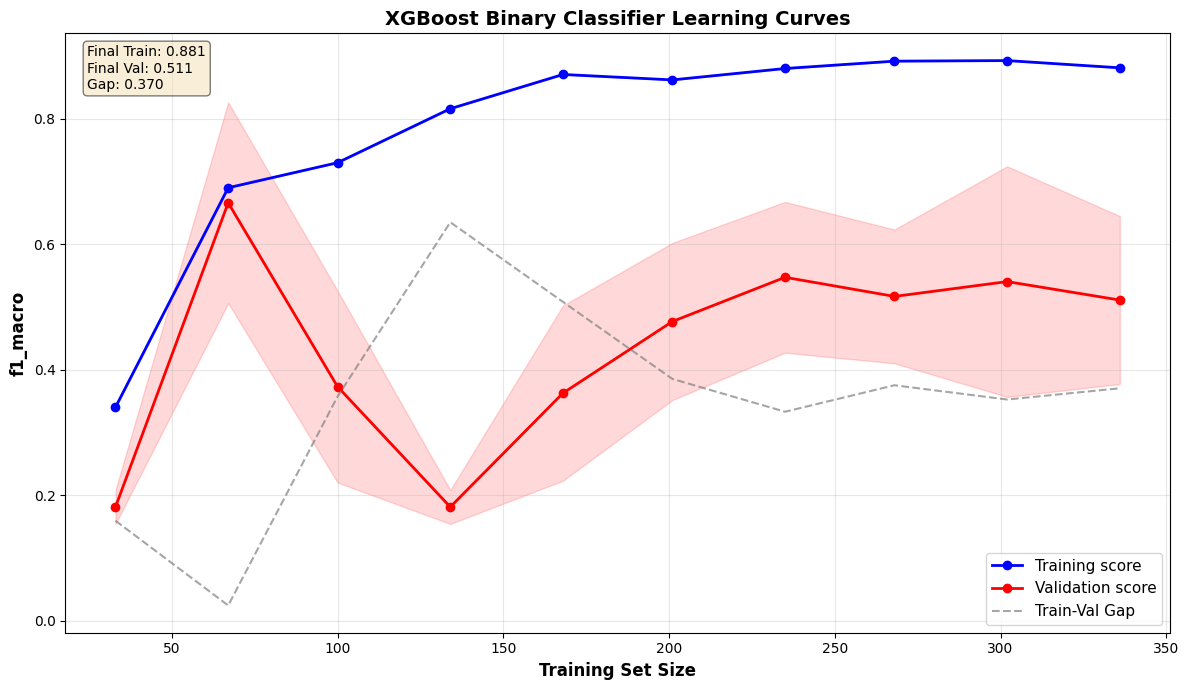

✓ Learning curves complete
  Final training score: 0.8810
  Final validation score: 0.5108
  Train-val gap: 0.3702
  ⚠ Warning: Large gap suggests overfitting



In [15]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Recreate a fresh estimator with the same parameters
    xgb_for_learning_curve = clone(best_xgb_model)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = model_utils.map_target_to_binary(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost Binary Classifier'
    )

## 12. Stage 5: Model Evaluation

In [16]:
from sklearn.metrics import classification_report

if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# Use the dataset associated with the selected XGBoost run
test_dataset = best_dataset
X_test = test_dataset["test_df"][best_xgb_feature_columns].fillna(0)
y_test_raw = test_dataset["test_df"][cfg.TARGET_COLUMN].astype(int)
y_test_binary = model_utils.map_target_to_binary(y_test_raw)

y_pred_proba = best_xgb_model.predict_proba(X_test)
y_pred_binary = (y_pred_proba[:, 1] >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test_binary, y_pred_binary)

print(f"\n✓ XGBoost Test Evaluation")
print(f"  Test Accuracy (binary target): {test_accuracy:.4f}")
print("\nClassification Report (binary target):")
print(classification_report(y_test_binary, y_pred_binary, target_names=["Non-positive", "Positive"]))


✓ XGBoost Test Evaluation
  Test Accuracy (binary target): 0.5874

Classification Report (binary target):
              precision    recall  f1-score   support

Non-positive       0.63      0.82      0.71       989
    Positive       0.43      0.22      0.29       618

    accuracy                           0.59      1607
   macro avg       0.53      0.52      0.50      1607
weighted avg       0.55      0.59      0.55      1607



## 13. Visualizations

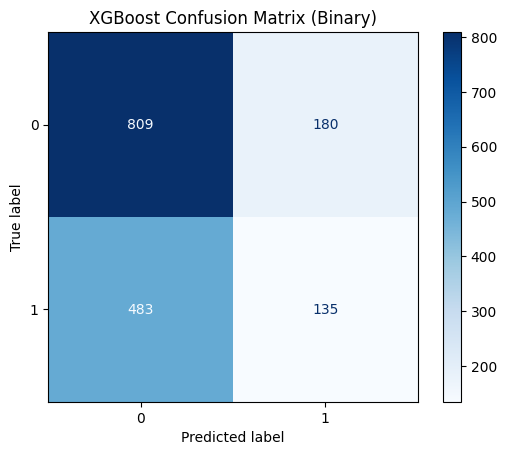

In [17]:
# Confusion matrix (binary target)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Binary)')
plt.show()

/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


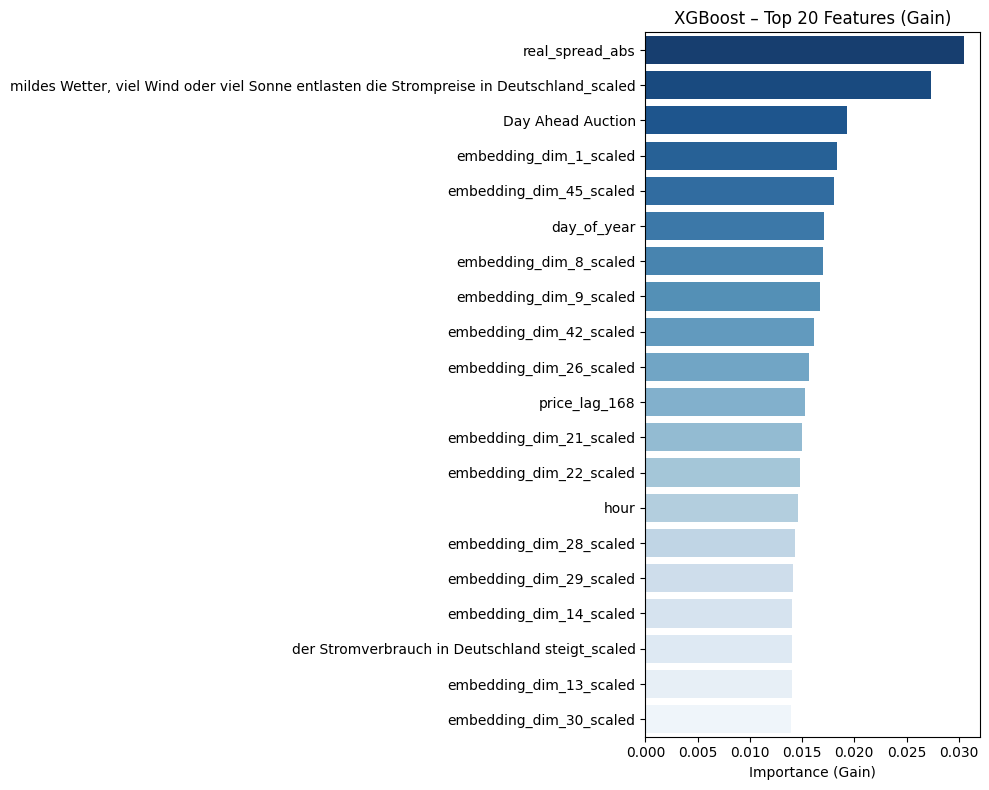

In [18]:
# Feature importance
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Stage 6: LightGBM Signal Modelling


In [19]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 80
  Baseline feature count: 13
  XGBoost features added: ['xgb_prob_class0', 'xgb_prob_class1', 'xgb_pred']


In [20]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [21]:
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(
    f"LightGBM device: {lgbm_device_config.get('description')} • "
    f"backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • "
    f"jobs={lgbm_device_config.get('n_jobs')}"
)

# Sanitize feature names for LightGBM (German characters cause JSON errors)
signal_feature_columns_sanitized, signal_name_mapping = model_utils.sanitize_feature_names(signal_feature_columns)

# Create mapping from original to sanitized names
signal_column_rename_map = dict(zip(signal_feature_columns, signal_feature_columns_sanitized))

# Prepare training data with sanitized column names
train_signal_X_renamed = signal_train_df[signal_feature_columns].fillna(0).rename(columns=signal_column_rename_map)

base_signal_splitter = model_utils.ExpandingWindowSplitter(
    n_splits=cfg.N_CV_SPLITS,
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)
available_signal_splits = base_signal_splitter.get_n_splits(train_signal_X_renamed)
if available_signal_splits == 0:
    raise ValueError("Insufficient data for LightGBM signal cross-validation.")

signal_cv = model_utils.ExpandingWindowSplitter(
    n_splits=min(cfg.N_CV_SPLITS, available_signal_splits),
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)

with profiling.StageProfiler("Stage 6A: LightGBM Signal Model", device_config):
    signal_lgbm_grid = model_utils.run_lgbm_grid_search(
        X_train=train_signal_X_renamed,
        y_train=y_train_signal,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        cv=signal_cv,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE,
    )

signal_best_lgbm = signal_lgbm_grid.best_estimator_
print("\n✓ LightGBM signal model trained")
print("  Best params:", signal_lgbm_grid.best_params_)
print(f"  Best CV macro-F1: {signal_lgbm_grid.best_score_:.3f}")


✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 6A: LightGBM Signal Model — starting
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[Stage ✅] Stage 6A: LightGBM Signal Model — completed in 46.22s
  CPU usage: 96.1% • IO wait: 0.00%
  Disk Δ: +475.9 MB read, +207.5 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ LightGBM signal model trained
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
  Best CV macro-F1: 0.550


In [22]:
# Sanitize baseline feature names for LightGBM
baseline_feature_columns_sanitized, baseline_name_mapping = model_utils.sanitize_feature_names(baseline_feature_columns)

# Create mapping from original to sanitized names
baseline_column_rename_map = dict(zip(baseline_feature_columns, baseline_feature_columns_sanitized))

# Prepare training data with sanitized column names
train_baseline_X_renamed = signal_train_df[baseline_feature_columns].fillna(0).rename(columns=baseline_column_rename_map)

base_baseline_splitter = model_utils.ExpandingWindowSplitter(
    n_splits=cfg.N_CV_SPLITS,
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)
available_baseline_splits = base_baseline_splitter.get_n_splits(train_baseline_X_renamed)
if available_baseline_splits == 0:
    raise ValueError("Insufficient data for LightGBM baseline cross-validation.")

baseline_cv = model_utils.ExpandingWindowSplitter(
    n_splits=min(cfg.N_CV_SPLITS, available_baseline_splits),
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)

with profiling.StageProfiler("Stage 6B: LightGBM Baseline Model", device_config):
    baseline_lgbm_grid = model_utils.run_lgbm_grid_search(
        X_train=train_baseline_X_renamed,
        y_train=y_train_signal,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        cv=baseline_cv,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE,
    )

baseline_best_lgbm = baseline_lgbm_grid.best_estimator_
print("\n✓ LightGBM baseline model trained")
print("  Best params:", baseline_lgbm_grid.best_params_)
print(f"  Best CV macro-F1: {baseline_lgbm_grid.best_score_:.3f}")



[Stage ⏳] Stage 6B: LightGBM Baseline Model — starting
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[Stage ✅] Stage 6B: LightGBM Baseline Model — completed in 37.89s
  CPU usage: 97.6% • IO wait: 0.00%
  Disk Δ: +120.9 MB read, +128.3 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ LightGBM baseline model trained
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
  Best CV macro-F1: 0.380


In [23]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.485, Macro-F1=0.355
  Baseline model → Acc=0.526, Macro-F1=0.385


## 15. Stage 7: Evaluation, Visualization & Backtesting


In [24]:
from sklearn.metrics import classification_report

signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

print("Signal Model Classification Report:")
print(classification_report(y_test_signal, signal_test_pred, target_names=label_encoder.classes_.astype(str)))

print("Baseline Model Classification Report:")
print(classification_report(y_test_signal, baseline_test_pred, target_names=label_encoder.classes_.astype(str)))


✓ LightGBM Test Performance
  Signal model  → Acc=0.408, Macro-F1=0.310
  Baseline model → Acc=0.436, Macro-F1=0.329

Signal Model Classification Report:
              precision    recall  f1-score   support

          -1       0.39      0.64      0.49       582
           0       0.00      0.00      0.00       407
           1       0.43      0.46      0.44       618

    accuracy                           0.41      1607
   macro avg       0.27      0.37      0.31      1607
weighted avg       0.31      0.41      0.35      1607

Baseline Model Classification Report:
              precision    recall  f1-score   support

          -1       0.42      0.73      0.54       582
           0       0.00      0.00      0.00       407
           1       0.45      0.45      0.45       618

    accuracy                           0.44      1607
   macro avg       0.29      0.39      0.33      1607
weighted avg       0.33      0.44      0.37      1607



/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [25]:
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
statistical_results



STATISTICAL MODEL COMPARISON

Signal accuracy:   0.4082
Baseline accuracy: 0.4356

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       465
Only signal correct:       191
Only baseline correct:     235
Both models wrong:         716

Signal model correct:      656
Baseline model correct:    700

McNemar's χ² statistic:    4.3404
p-value:                   0.0372

✓ Signal model is SIGNIFICANTLY better (p < 0.05) *


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.4084 [0.3864, 0.4325]
Baseline model: 0.4356 [0.4107, 0.4599]
Difference:     -0.0272

○ Confidence intervals overlap - weaker evidence of difference




{'mcnemar_statistic': np.float64(4.34037558685446),
 'mcnemar_p_value': np.float64(0.03721871223035189),
 'signal_acc_mean': np.float64(0.4083677660236465),
 'signal_acc_ci': (np.float64(0.3864343497199751),
  np.float64(0.432482887367766)),
 'baseline_acc_mean': np.float64(0.4355581829495956),
 'baseline_acc_ci': (np.float64(0.41070317361543246),
  np.float64(0.4598786558805227))}

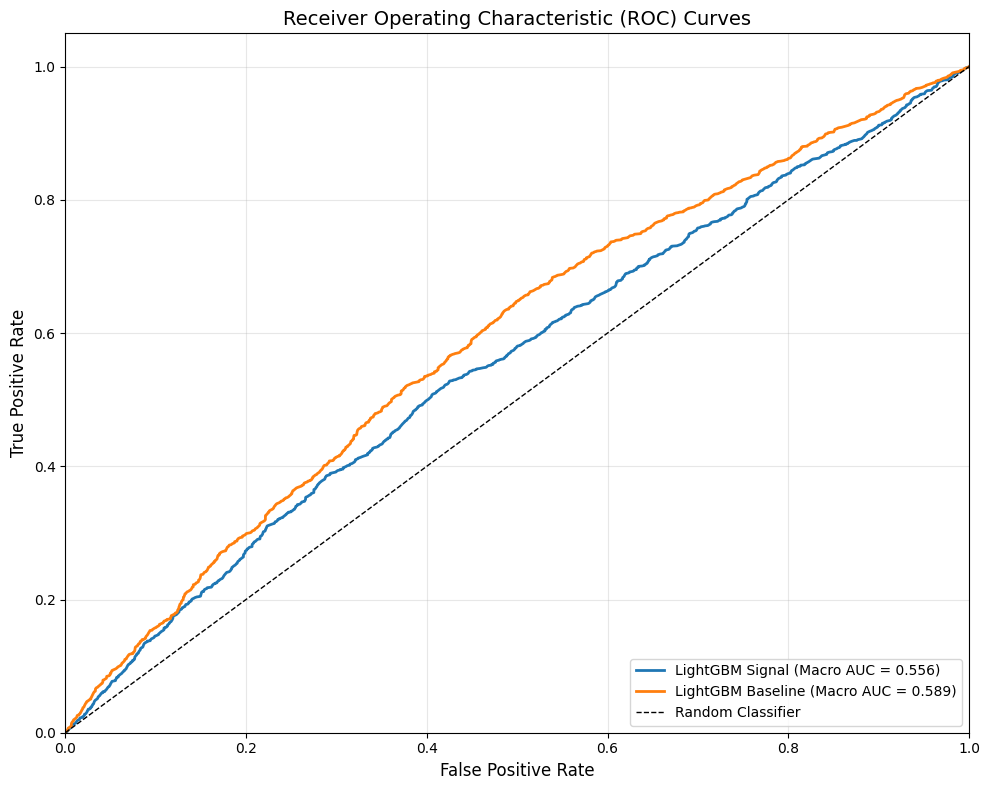

{'LightGBM Signal': 0.5555119036674421,
 'LightGBM Baseline': 0.5894953779906074}

In [26]:
# Plot ROC curves for both models
visualization.plot_roc_curves(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder,
    multiclass_average='macro'
)


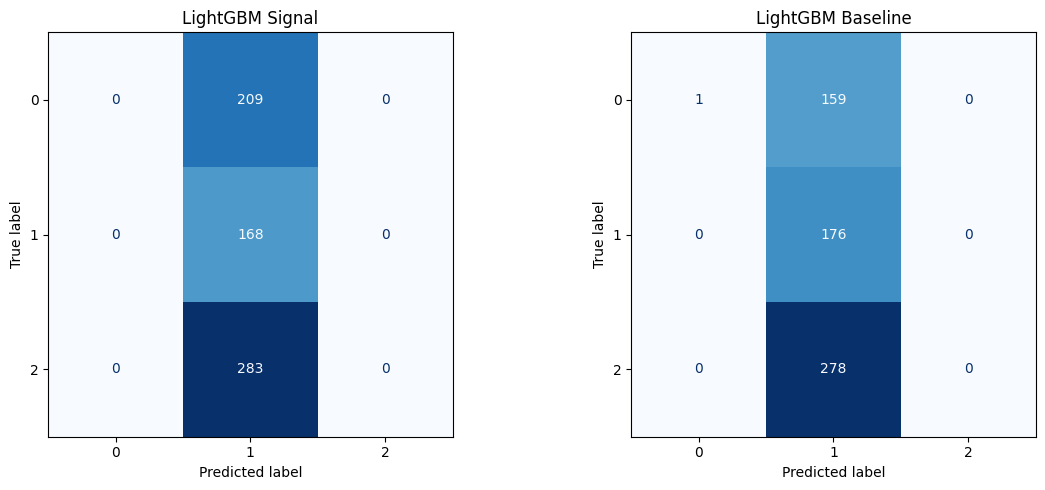

In [27]:
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    class_labels=list(range(len(label_encoder.classes_))),
    label_encoder=label_encoder,
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),4899.71,3.048979,33.300101,8.569609,7.993660,-2190.95,56.876167,1607
LightGBM Baseline (price-only),10720.32,6.671014,32.766116,19.055439,15.052046,-1846.07,68.617684,1606
Naive Buy-DA/Sell-Spot,3244.71,2.019110,33.378428,5.661691,8.994121,-1399.64,51.586808,1607


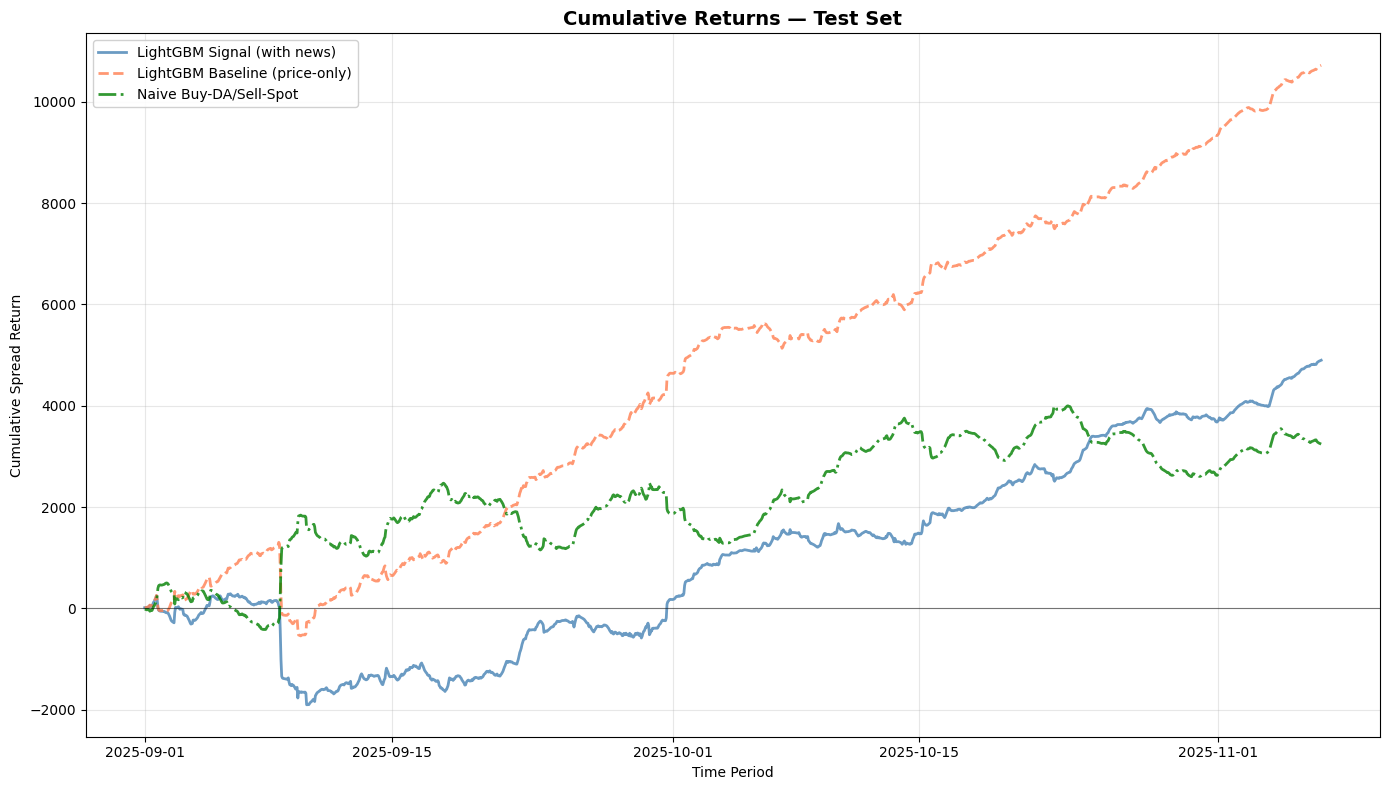

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [28]:
spot_col = evaluation.get_column_name([
    "Spot Price", "spot_price", "SpotPrice"
], signal_test_df)
day_ahead_col = evaluation.get_column_name([
    "Day Ahead Auction", "day_ahead_price", "DayAhead"
], signal_test_df)

if spot_col is None or day_ahead_col is None:
    raise KeyError("Could not identify spot or day-ahead price columns for backtesting.")

spot_series = signal_test_df[spot_col]
day_ahead_series = signal_test_df[day_ahead_col]
spread_series = spot_series - day_ahead_series

strategy_actions = {
    "LightGBM Signal (with news)": signal_test_decoded,
    "LightGBM Baseline (price-only)": baseline_test_decoded,
    "Naive Buy-DA/Sell-Spot": np.ones_like(signal_test_decoded, dtype=int),
}

strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)

display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


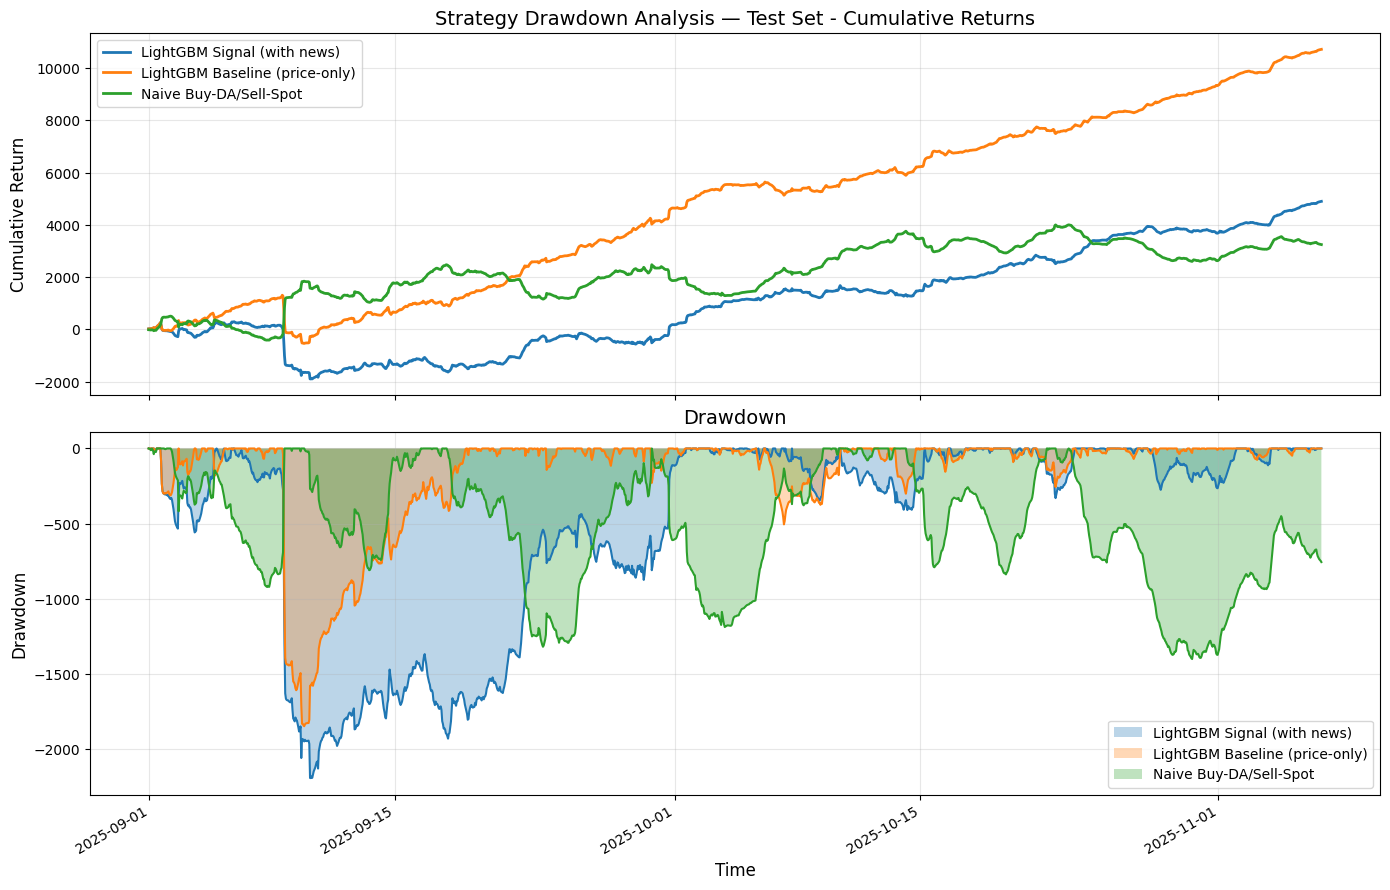

In [29]:
# Plot drawdown analysis
visualization.plot_drawdown_chart(
    returns_map=strategy_returns,
    title="Strategy Drawdown Analysis — Test Set"
)


LightGBM Signal Feature Importance


/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


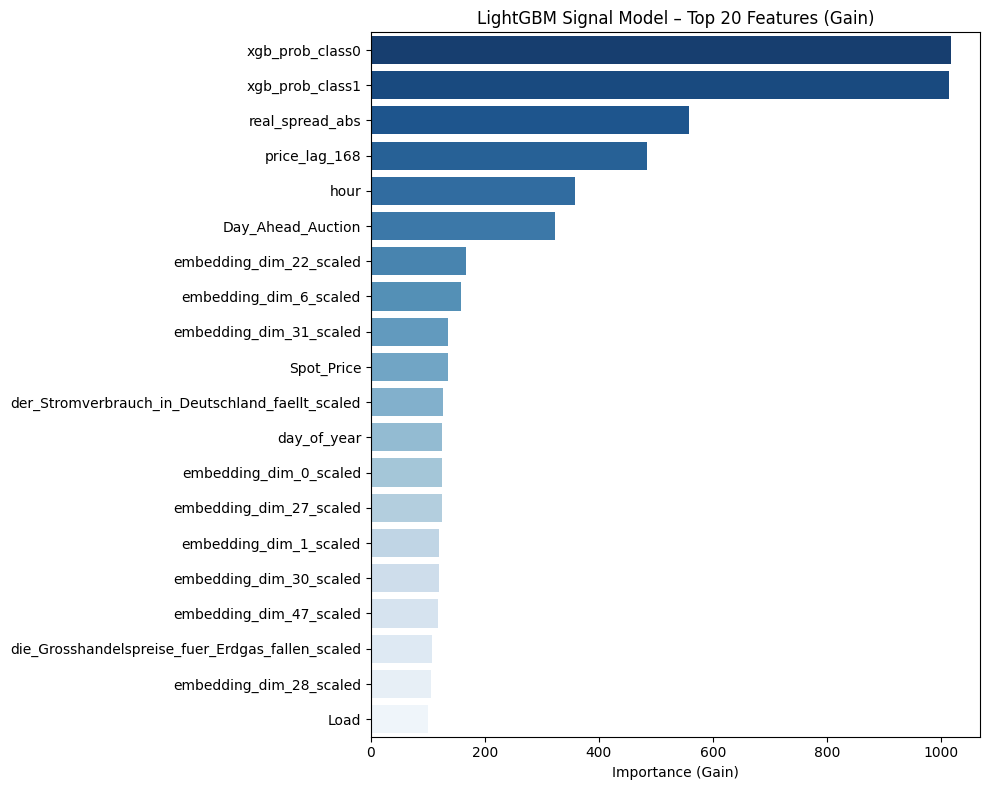

LightGBM Baseline Feature Importance


/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


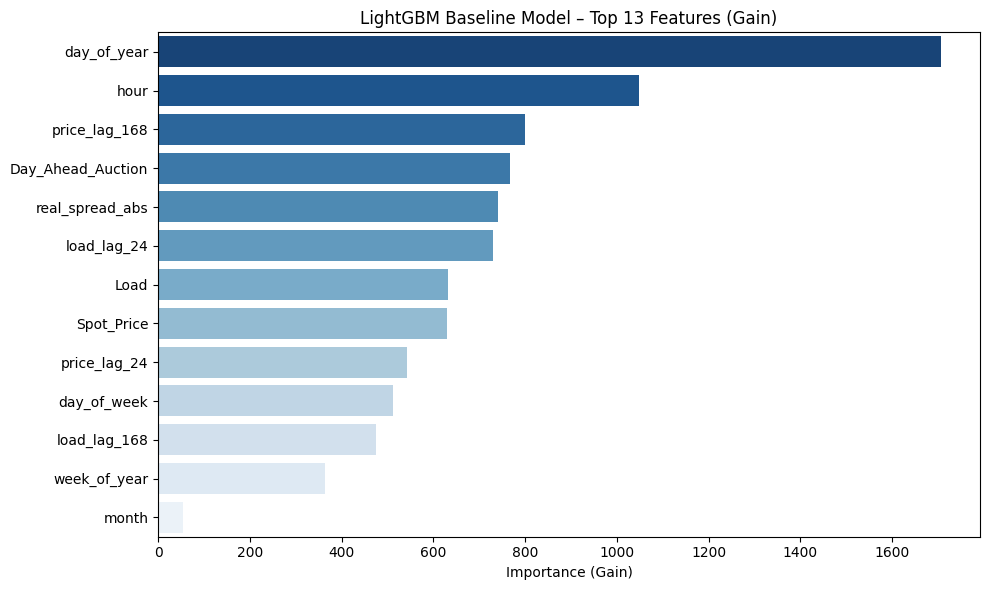

,feature,importance
0,day_of_year,1706
1,hour,1048
2,price_lag_168,799
3,Day_Ahead_Auction,768
4,real_spread_abs,741
5,load_lag_24,730
6,Load,632
7,Spot_Price,630
8,price_lag_24,542
9,day_of_week,512


In [30]:
print("LightGBM Signal Feature Importance")
visualization.plot_feature_importance(
    model=signal_best_lgbm,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
    top_n=20,
)

print("LightGBM Baseline Feature Importance")
visualization.plot_feature_importance(
    model=baseline_best_lgbm,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
    top_n=20,
)



BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          4899.71             8.569609              7.993660
LightGBM Baseline (price-only)      10720.32            19.055439             15.052046
Naive Buy-DA/Sell-Spot               3244.71             5.661691              8.994121

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          4096.21             7.164285              6.778291
LightGBM Baseline (price-only)       9917.32            17.628134             14.180899
Naive Buy-DA/Sell-Spot               2441.21             4.2596

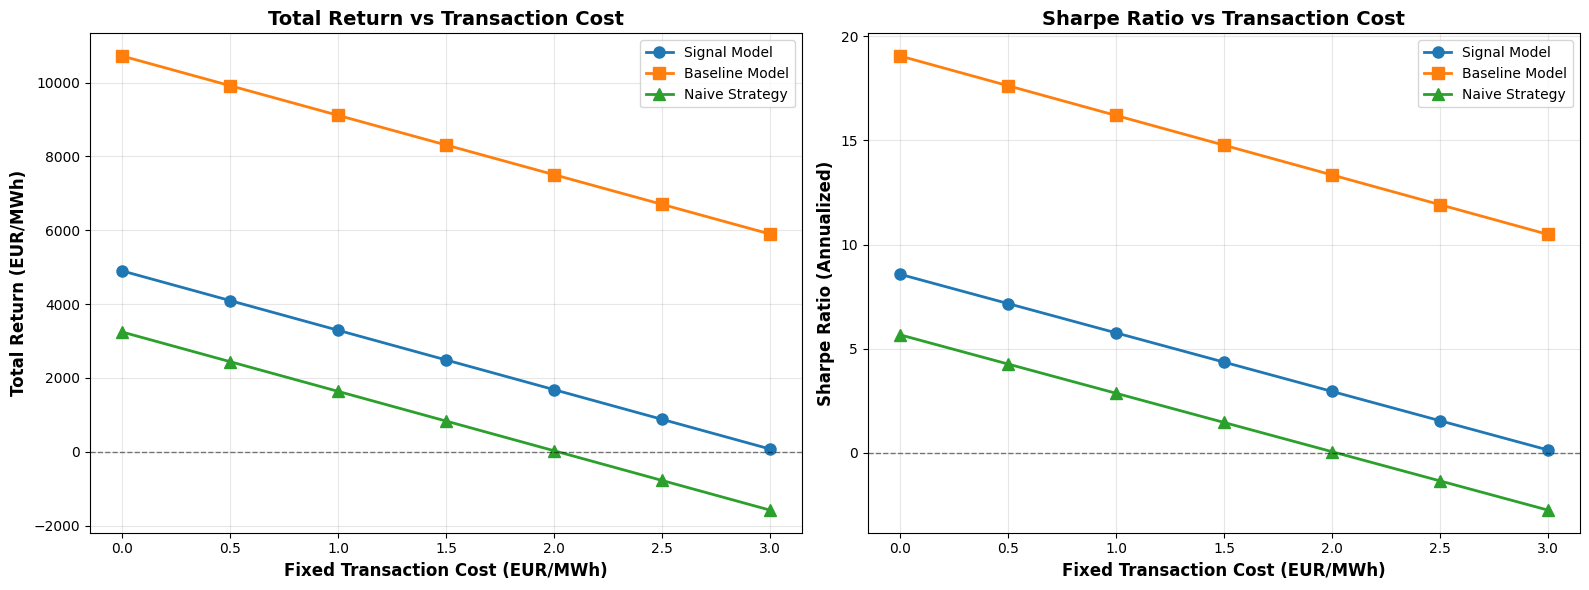

In [31]:
# Evaluate strategies with transaction costs
print("\n" + "=" * 80)
print("BACKTESTING WITH TRANSACTION COSTS")
print("=" * 80)

# Define transaction cost scenarios
transaction_cost_scenarios = {
    "No Costs": (0.0, 0.0),
    "Low Cost (€0.5/MWh)": (0.5, 0.0),
    "Medium Cost (€1.0/MWh)": (1.0, 0.0),
    "High Cost (€2.0/MWh + 0.1%)": (2.0, 0.001),
}

# Compute returns for each scenario
for scenario_name, (fixed_cost, pct_cost) in transaction_cost_scenarios.items():
    print(f"\n{scenario_name}:")
    print(f"  Fixed: €{fixed_cost}/MWh, Percentage: {pct_cost*100:.2f}%")
    
    strategy_returns_cost = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=fixed_cost,
        transaction_cost_pct=pct_cost
    )
    
    returns_summary_cost = evaluation.summarise_strategy_set(strategy_returns_cost)
    print(f"\n{returns_summary_cost[['Total Return', 'Sharpe (annualised)', 'Sortino (annualised)']].to_string()}")

# Visualize impact of transaction costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total return vs transaction cost
costs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
signal_returns = []
baseline_returns = []
naive_returns = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    signal_returns.append(temp_returns["LightGBM Signal (with news)"].sum())
    baseline_returns.append(temp_returns["LightGBM Baseline (price-only)"].sum())
    naive_returns.append(temp_returns["Naive Buy-DA/Sell-Spot"].sum())

ax1.plot(costs, signal_returns, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax1.plot(costs, baseline_returns, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax1.plot(costs, naive_returns, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Return (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_title('Total Return vs Transaction Cost', fontweight='bold', fontsize=14)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Right: Sharpe ratio vs transaction cost
signal_sharpes = []
baseline_sharpes = []
naive_sharpes = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    temp_summary = evaluation.summarise_strategy_set(temp_returns)
    signal_sharpes.append(temp_summary.loc["LightGBM Signal (with news)", "Sharpe (annualised)"])
    baseline_sharpes.append(temp_summary.loc["LightGBM Baseline (price-only)", "Sharpe (annualised)"])
    naive_sharpes.append(temp_summary.loc["Naive Buy-DA/Sell-Spot", "Sharpe (annualised)"])

ax2.plot(costs, signal_sharpes, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax2.plot(costs, baseline_sharpes, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax2.plot(costs, naive_sharpes, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Sharpe Ratio (Annualized)', fontweight='bold', fontsize=12)
ax2.set_title('Sharpe Ratio vs Transaction Cost', fontweight='bold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

## 17. Transaction Cost Sensitivity Analysis

SIGNAL MODEL - PERMUTATION IMPORTANCE

COMPUTING PERMUTATION IMPORTANCE FOR LIGHTGBM SIGNAL MODEL


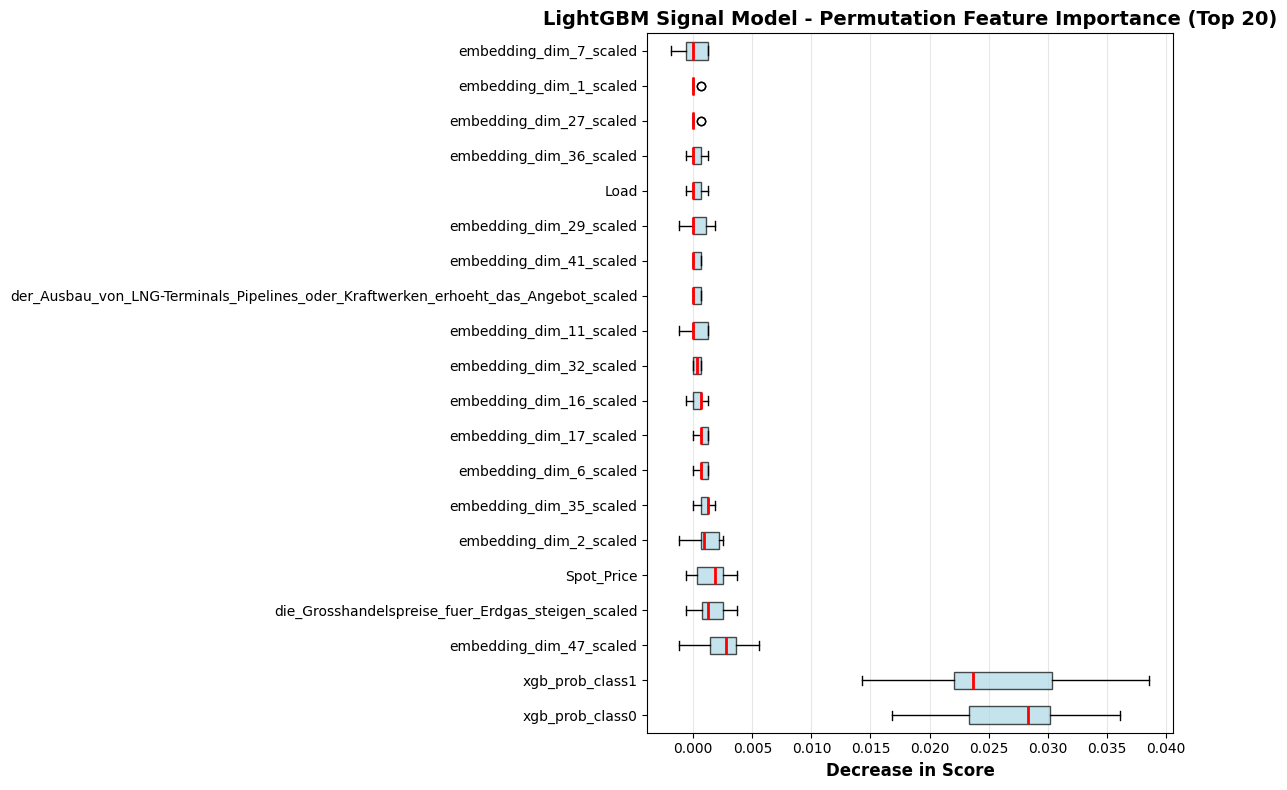

✓ Permutation importance complete
  Top 5 features:
    1. xgb_prob_class0: 0.0269 ± 0.0058
    2. xgb_prob_class1: 0.0255 ± 0.0071
    3. embedding_dim_47_scaled: 0.0026 ± 0.0019
    4. die_Grosshandelspreise_fuer_Erdgas_steigen_scaled: 0.0016 ± 0.0014
    5. Spot_Price: 0.0016 ± 0.0015



In [32]:
# Permutation importance for signal model
print("=" * 80)
print("SIGNAL MODEL - PERMUTATION IMPORTANCE")
print("=" * 80)
visualization.plot_permutation_importance(
    model=signal_best_lgbm,
    X_test=test_signal_X,
    y_test=y_test_signal,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
    n_repeats=10,
    top_n=20
)